In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [6]:
data=pd.read_csv('/content/Wine_clust.csv')

In [7]:
df = pd.read_csv("Wine_clust.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [9]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [10]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64


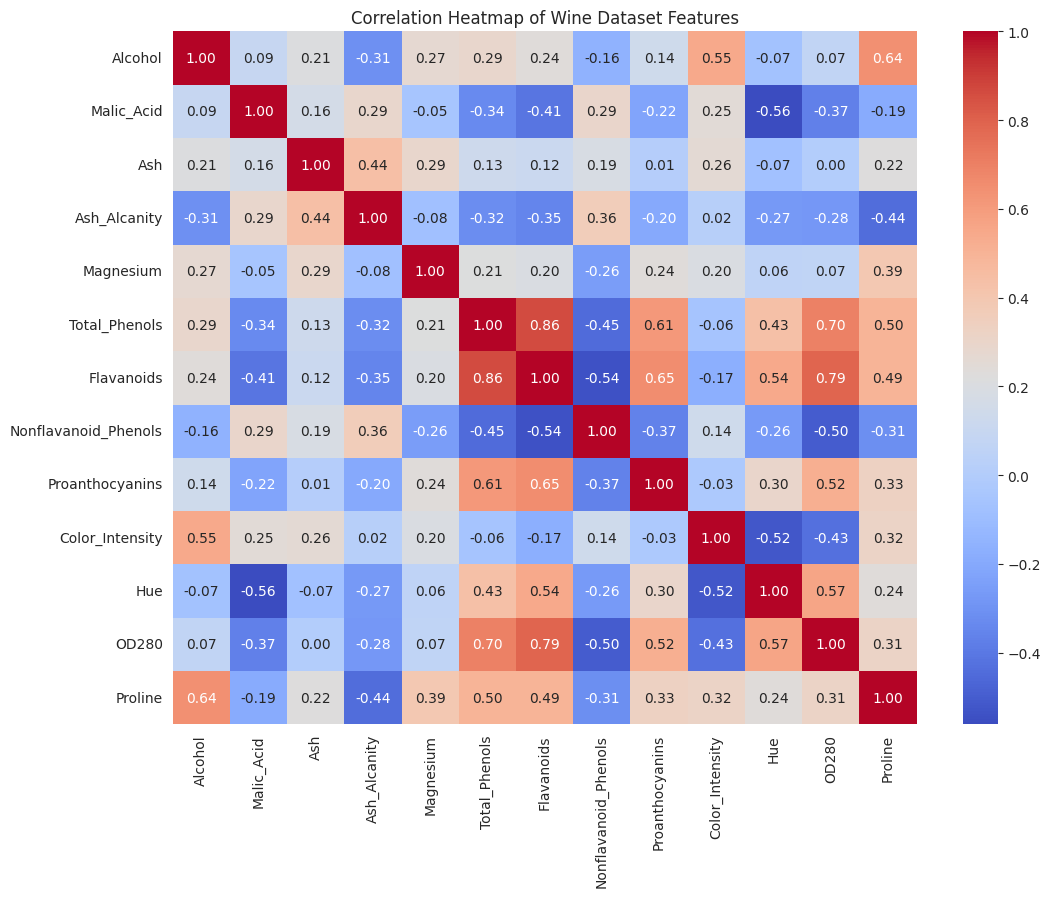

In [11]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Wine Dataset Features")
plt.show()

#data preprocessing

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("Scaled data shape:", X_scaled.shape)
print(X_scaled[:5])

Scaled data shape: (178, 13)
[[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
   1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
   1.01300893]
 [ 0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502  0.56864766
   0.73362894 -0.82071924 -0.54472099 -0.29332133  0.40605066  1.1134493
   0.96524152]
 [ 0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836  0.80899739
   1.21553297 -0.49840699  2.13596773  0.26901965  0.31830389  0.78858745
   1.39514818]
 [ 1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845  2.49144552
   1.46652465 -0.98187536  1.03215473  1.18606801 -0.42754369  1.18407144
   2.33457383]
 [ 0.29570023  0.22769377  1.84040254  0.45194578  1.28198515  0.80899739
   0.66335127  0.22679555  0.40140444 -0.31927553  0.36217728  0.44960118
  -0.03787401]]


#
We will also reduce the scaled data to 2 dimensions using PCA, purely for visualization of the clusters formed by each model. The clustering itself is performed on the full scaled feature set.

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio by 2 components:", pca.explained_variance_ratio_)
print("Total variance captured:", round(sum(pca.explained_variance_ratio_) * 100, 2), "%")

Explained variance ratio by 2 components: [0.36198848 0.1920749 ]
Total variance captured: 55.41 %


#5. K-Means Clustering
#5.1 Finding the Optimum Number of Clusters (Elbow Method)

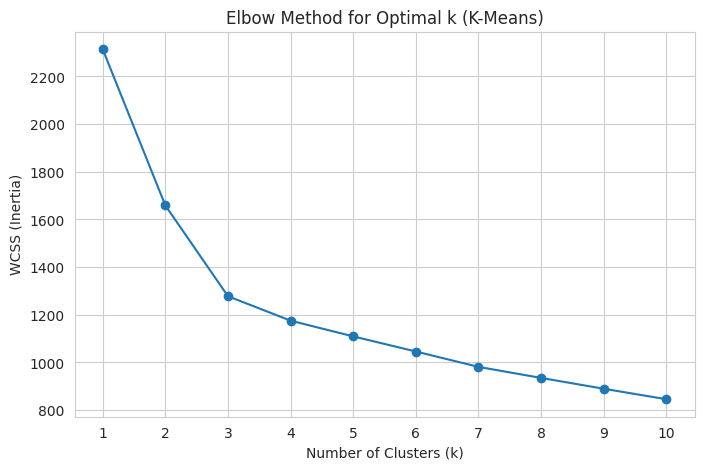

In [15]:
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(list(k_range), wcss, marker="o")
plt.title("Elbow Method for Optimal k (K-Means)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(list(k_range))
plt.show()

### 5.2 Confirming Optimum k using Silhouette Score

k = 2, Silhouette Score = 0.2593
k = 3, Silhouette Score = 0.2849
k = 4, Silhouette Score = 0.2602
k = 5, Silhouette Score = 0.2016
k = 6, Silhouette Score = 0.2372
k = 7, Silhouette Score = 0.2036
k = 8, Silhouette Score = 0.1570
k = 9, Silhouette Score = 0.1499
k = 10, Silhouette Score = 0.1436


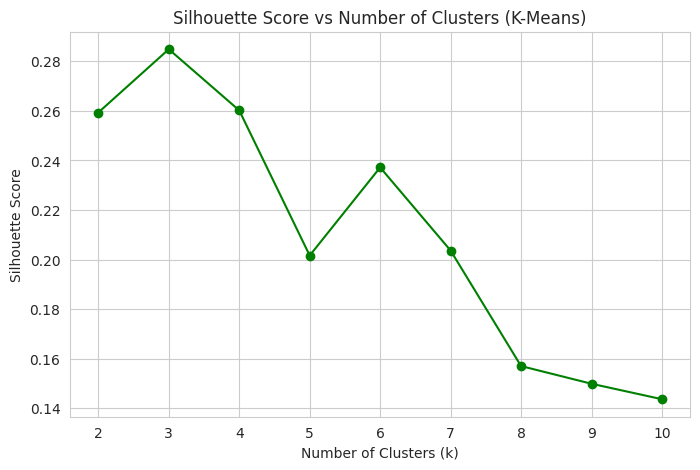

In [16]:
sil_scores_kmeans = []
k_range_sil = range(2, 11)
for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores_kmeans.append(score)
    print(f"k = {k}, Silhouette Score = {score:.4f}")

plt.plot(list(k_range_sil), sil_scores_kmeans, marker="o", color="green")
plt.title("Silhouette Score vs Number of Clusters (K-Means)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_range_sil))
plt.show()

In [17]:
best_k = list(k_range_sil)[np.argmax(sil_scores_kmeans)]
print("Optimum number of clusters for K-Means (highest silhouette score):", best_k)

Optimum number of clusters for K-Means (highest silhouette score): 3


#5.3 Final K-Means Model with Optimum Clusters

In [18]:
kmeans_final = KMeans(n_clusters=best_k, init="k-means++", random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels
print("Cluster counts:")
print(df["KMeans_Cluster"].value_counts().sort_index())
print("\nFinal Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))

Cluster counts:
KMeans_Cluster
0    65
1    51
2    62
Name: count, dtype: int64

Final Silhouette Score: 0.2848589191898987


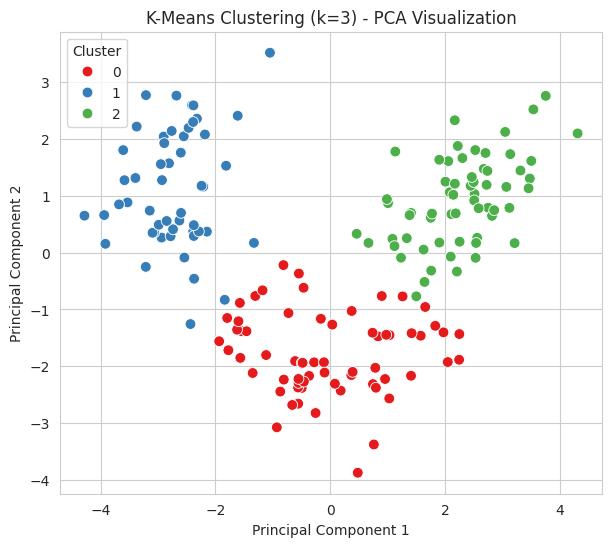

In [19]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette="Set1", s=60)
plt.title(f"K-Means Clustering (k={best_k}) - PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

6. Agglomerative (Hierarchical) Clustering
6.1 Dendrogram to Visualize Cluster Merging

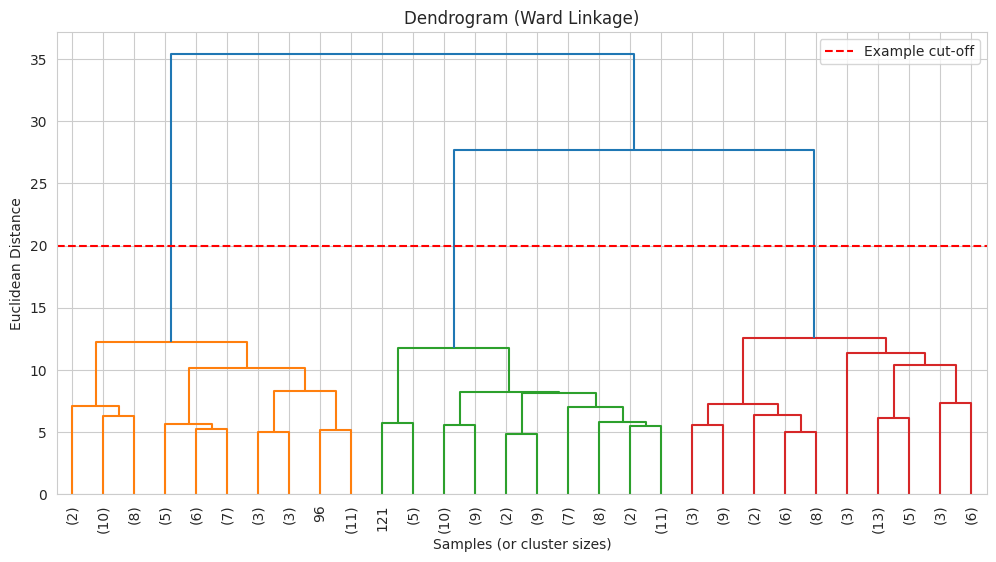

In [20]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=10)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Samples (or cluster sizes)")
plt.ylabel("Euclidean Distance")
plt.axhline(y=20, color="red", linestyle="--", label="Example cut-off")
plt.legend()
plt.show()

#6.2 Finding the Optimum Number of Clusters using Silhouette Score

k = 2, Silhouette Score = 0.2670
k = 3, Silhouette Score = 0.2774
k = 4, Silhouette Score = 0.2258
k = 5, Silhouette Score = 0.1867
k = 6, Silhouette Score = 0.1797
k = 7, Silhouette Score = 0.1869
k = 8, Silhouette Score = 0.1883
k = 9, Silhouette Score = 0.1917
k = 10, Silhouette Score = 0.1986


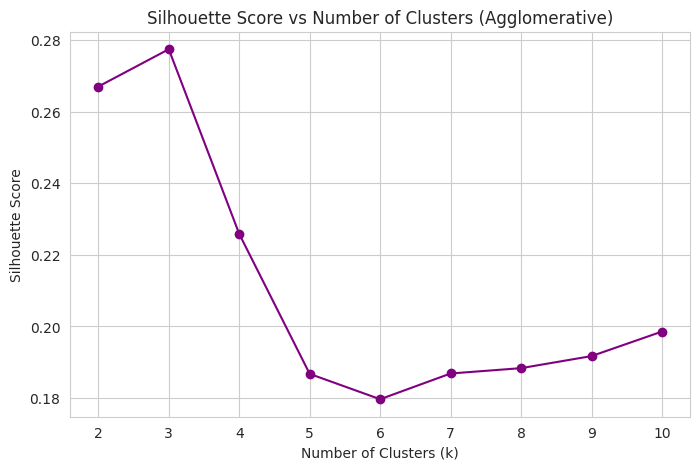

In [21]:
sil_scores_agg = []
k_range_agg = range(2, 11)
for k in k_range_agg:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores_agg.append(score)
    print(f"k = {k}, Silhouette Score = {score:.4f}")

plt.plot(list(k_range_agg), sil_scores_agg, marker="o", color="purple")
plt.title("Silhouette Score vs Number of Clusters (Agglomerative)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_range_agg))
plt.show()

In [22]:
best_k_agg = list(k_range_agg)[np.argmax(sil_scores_agg)]
print("Optimum number of clusters for Agglomerative Clustering:", best_k_agg)

Optimum number of clusters for Agglomerative Clustering: 3


#
6.3 Final Agglomerative Model with Optimum Clusters

In [23]:
agg_final = AgglomerativeClustering(n_clusters=best_k_agg, linkage="ward")
agg_labels = agg_final.fit_predict(X_scaled)

df["Agglomerative_Cluster"] = agg_labels
print("Cluster counts:")
print(df["Agglomerative_Cluster"].value_counts().sort_index())
print("\nFinal Silhouette Score:", silhouette_score(X_scaled, agg_labels))

Cluster counts:
Agglomerative_Cluster
0    58
1    56
2    64
Name: count, dtype: int64

Final Silhouette Score: 0.2774439826952265


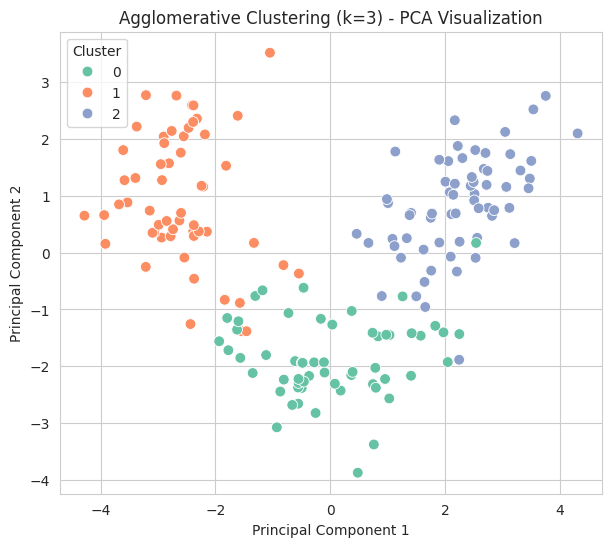

In [24]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agg_labels, palette="Set2", s=60)
plt.title(f"Agglomerative Clustering (k={best_k_agg}) - PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

## 7. DBSCAN Clustering

### 7.1 K-Distance Plot to Choose `eps`

DBSCAN does not require the number of clusters upfront, but it needs `eps` and `min_samples`. A common approach is to plot the distance to the k-th nearest neighbor (k = min_samples) and look for the "elbow" point.

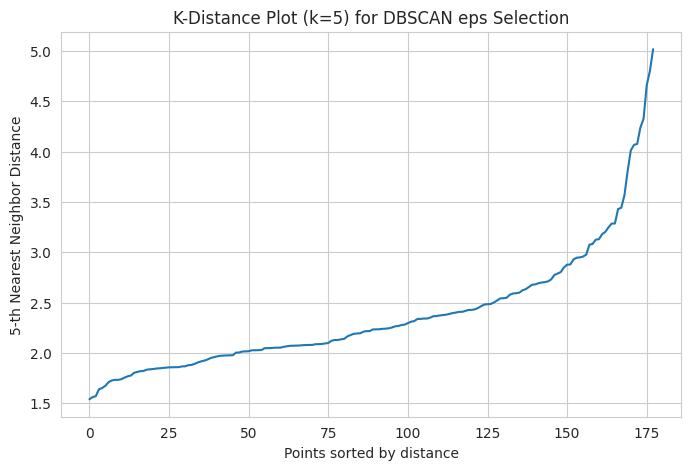

In [25]:
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:, min_samples - 1])

plt.plot(k_distances)
plt.title(f"K-Distance Plot (k={min_samples}) for DBSCAN eps Selection")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-th Nearest Neighbor Distance")
plt.show()

#7.2 Searching for the Optimum eps using Silhouette Score
Using the elbow region identified above as a guide, we scan a range of eps values and pick the one that gives the best silhouette score (ignoring noise points labeled -1).

In [26]:
eps_values = np.arange(1.5, 4.1, 0.1)
best_eps = None
best_score = -1
best_labels = None
results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters >= 2:
        mask = labels != -1
        if mask.sum() > 1 and len(set(labels[mask])) >= 2:
            score = silhouette_score(X_scaled[mask], labels[mask])
        else:
            score = -1
    else:
        score = -1
    results.append((round(eps, 2), n_clusters, round(score, 4)))
    if score > best_score:
        best_score = score
        best_eps = eps
        best_labels = labels

results_df = pd.DataFrame(results, columns=["eps", "n_clusters", "silhouette_score"])
print(results_df)
print("\nBest eps:", round(best_eps, 2), "| Best silhouette score:", round(best_score, 4))

    eps  n_clusters  silhouette_score
0   1.5           0           -1.0000
1   1.6           3            0.5021
2   1.7           6            0.3943
3   1.8           7            0.2462
4   1.9           6            0.3490
5   2.0           5            0.2405
6   2.1           3            0.2217
7   2.2           2            0.3480
8   2.3           2            0.3307
9   2.4           2            0.3266
10  2.5           1           -1.0000
11  2.6           1           -1.0000
12  2.7           1           -1.0000
13  2.8           1           -1.0000
14  2.9           1           -1.0000
15  3.0           1           -1.0000
16  3.1           1           -1.0000
17  3.2           1           -1.0000
18  3.3           1           -1.0000
19  3.4           1           -1.0000
20  3.5           1           -1.0000
21  3.6           1           -1.0000
22  3.7           1           -1.0000
23  3.8           1           -1.0000
24  3.9           1           -1.0000
25  4.0     

#
7.3 Final DBSCAN Model with Optimum Parameters

In [27]:
dbscan_final = DBSCAN(eps=best_eps, min_samples=min_samples)
dbscan_labels = dbscan_final.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("Optimum eps:", round(best_eps, 2), "| min_samples:", min_samples)
print("Number of clusters found:", n_clusters_db)
print("Number of noise points:", n_noise)
print("\nCluster counts:")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

Optimum eps: 1.6 | min_samples: 5
Number of clusters found: 3
Number of noise points: 162

Cluster counts:
DBSCAN_Cluster
-1    162
 0      5
 1      6
 2      5
Name: count, dtype: int64


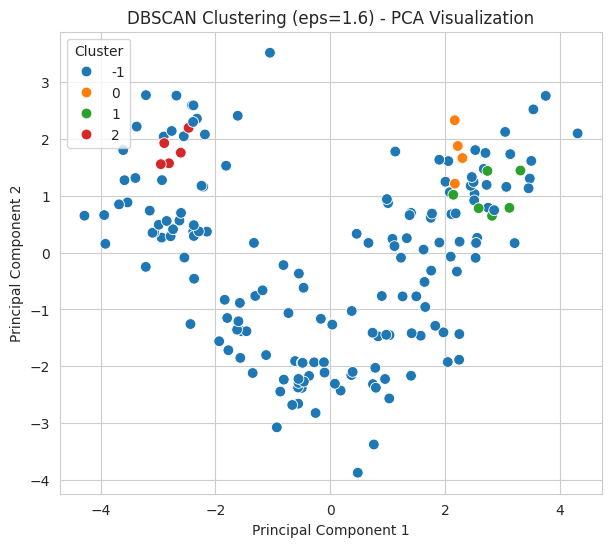

In [28]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette="tab10", s=60)
plt.title(f"DBSCAN Clustering (eps={round(best_eps,2)}) - PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

#8. Comparison of Clustering Models

In [29]:
comparison = pd.DataFrame({
    "Model": ["K-Means", "Agglomerative (Hierarchical)", "DBSCAN"],
    "Optimum Parameter": [f"k={best_k}", f"k={best_k_agg}", f"eps={round(best_eps,2)}, min_samples={min_samples}"],
    "Number of Clusters": [best_k, best_k_agg, n_clusters_db],
    "Silhouette Score": [
        round(silhouette_score(X_scaled, kmeans_labels), 4),
        round(silhouette_score(X_scaled, agg_labels), 4),
        round(best_score, 4)
    ]
})
comparison

,Model,Optimum Parameter,Number of Clusters,Silhouette Score
0,K-Means,k=3,3,0.2849
1,Agglomerative (Hierarchical),k=3,3,0.2774
2,DBSCAN,"eps=1.6, min_samples=5",3,0.5021


#9. Conclusion
K-Means and Agglomerative Clustering both found their optimum cluster count using the silhouette score, and both align well with the fact that the Wine dataset is known to naturally form 3 groups (corresponding to 3 wine cultivars).
DBSCAN identifies clusters based on density and can also mark some points as noise (label -1); its optimum eps was chosen based on the silhouette score search combined with the k-distance elbow plot.
Comparing silhouette scores across models helps decide which clustering approach best fits the underlying structure of this dataset.